# Assessment 11: Market Basket Analysis
**Members: Carolino, Bryant Kenzo | Lavado, Sean Eldridge | Sy, Eibert Deane**

In [8]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules

---

## Task 1 — Data Loading & Aggregation

In [10]:
# 1. Load sen.csv and print shape + first 3 rows
df = pd.read_csv('C:\\Users\\Dell\\Documents\\UST Docs\\Sophomore\\2ND_SEM\\FINALS\\AI\\ass11\\sen.csv')
print('Shape:', df.shape)
df.head(3)

Shape: (105971, 71)


,Unnamed: 0,region,province,city,brgy,precinct,total_votes,sen_1_afuang,sen_2_albani,sen_3_arranza,...,sen_55_sahidulla,sen_56_sison,sen_57_teodoro,sen_58_trillanes,sen_59_tulfo,sen_60_valeros,sen_61_villanueva,sen_62_villar,sen_63_zubiaga,sen_64_zubiri
0,0,BARMM,BASILAN,AKBAR,CADDAYAN,7080005,1320,2,32,0,...,10,3,28,7,53,1,51,97,15,85
1,1,BARMM,BASILAN,AKBAR,LINONGAN,7080001,968,0,14,0,...,8,0,61,0,34,0,2,34,0,39
2,2,BARMM,BASILAN,AKBAR,LINONGAN,7080002,513,0,9,0,...,2,0,8,0,12,0,3,5,0,7


In [11]:
# 2. Extract senator columns and sum votes per province
sen_cols = [c for c in df.columns if c.startswith('sen_')]
prov_df = df.groupby('province')[sen_cols].sum()
print('Province-level shape:', prov_df.shape)
prov_df.head(3)

Province-level shape: (90, 64)


,sen_1_afuang,sen_2_albani,sen_3_arranza,sen_4_baguilat,sen_5_bailen,sen_6_balita,sen_7_barbo,sen_8_bautista,sen_9_belgica,sen_10_bello,...,sen_55_sahidulla,sen_56_sison,sen_57_teodoro,sen_58_trillanes,sen_59_tulfo,sen_60_valeros,sen_61_villanueva,sen_62_villar,sen_63_zubiaga,sen_64_zubiri
province,,,,,,,,,,,,,,,,,,,,,
ABRA,2651,1440,1180,4943,1515,9302,1740,29610,3379,3341,...,754,3252,41753,10637,60620,1441,47150,66591,1789,33614
AGUSAN DEL NORTE,5041,4044,4745,10533,4366,26471,17859,59368,22674,30060,...,2169,8555,126577,25764,125579,2252,127322,167114,6046,170708
AGUSAN DEL SUR,6064,4364,4239,7121,4574,18337,3862,44812,9553,7558,...,1981,6253,114525,24802,124860,2870,123189,132265,5884,146415


In [12]:
# 3. For each province, get top 8 senators by total votes (last name only)
def top8_senators(row):
    top = row.nlargest(8).index.tolist()
    # Extract last name: column format is sen_N_lastname
    return [col.split('_', 2)[-1] for col in top]

transactions = prov_df.apply(top8_senators, axis=1).tolist()

In [13]:
# 4. Print transaction list and verify count
print(f'Number of transactions (provinces): {len(transactions)}')
print('\nSample transactions:')
for province, txn in zip(prov_df.index[:5], transactions[:5]):
    print(f'  {province}: {txn}')

Number of transactions (provinces): 90

Sample transactions:
  ABRA: ['padilla', 'estrada', 'villar', 'binay', 'tulfo', 'ejercito', 'legarda', 'gatchalian']
  AGUSAN DEL NORTE: ['padilla', 'zubiri', 'legarda', 'villar', 'gatchalian', 'villanueva', 'teodoro', 'tulfo']
  AGUSAN DEL SUR: ['padilla', 'zubiri', 'legarda', 'cayetano', 'villar', 'gatchalian', 'ejercito', 'tulfo']
  AKLAN: ['legarda', 'tulfo', 'hontiveros', 'villanueva', 'escudero', 'padilla', 'gatchalian', 'villar']
  ALBAY: ['escudero', 'hontiveros', 'tulfo', 'trillanes', 'de_lima', 'legarda', 'cayetano', 'diokno']


---

## Task 2 — Frequent Itemset Mining

In [15]:
# 1. Encode transactions using TransactionEncoder
te = TransactionEncoder()
te_array = te.fit_transform(transactions)
te_df = pd.DataFrame(te_array, columns=te.columns_)
print('Encoded DataFrame shape:', te_df.shape)
te_df.head(3)

Encoded DataFrame shape: (90, 25)


,baguilat,bautista,binay,cayetano,de_lima,diokno,ejercito,eleazar,escudero,estrada,...,padilla,piñol,roque,sahidulla,teodoro,trillanes,tulfo,villanueva,villar,zubiri
0,False,False,True,False,False,False,True,False,False,True,...,True,False,False,False,False,False,True,False,True,False
1,False,False,False,False,False,False,False,False,False,False,...,True,False,False,False,True,False,True,True,True,True
2,False,False,False,True,False,False,True,False,False,False,...,True,False,False,False,False,False,True,False,True,True


In [16]:
# 2. Apply Apriori with min_support=0.3
frequent_itemsets = apriori(te_df, min_support=0.3, use_colnames=True)

# Fix frozenset string encoding
frequent_itemsets['itemsets'] = frequent_itemsets['itemsets'].apply(
    lambda x: frozenset(str(i) for i in x)
)

print(f'Number of frequent itemsets found: {len(frequent_itemsets)}')
frequent_itemsets.head()

Number of frequent itemsets found: 191


,support,itemsets
0,0.722222,frozenset({cayetano})
1,0.555556,frozenset({escudero})
2,0.377778,frozenset({estrada})
3,0.777778,frozenset({gatchalian})
4,0.977778,frozenset({legarda})


In [17]:
# 3. Add itemset_size column; display 2-itemsets and 3-itemsets
frequent_itemsets['itemset_size'] = frequent_itemsets['itemsets'].apply(len)

print('=== 2-Itemsets ===')
display(frequent_itemsets[frequent_itemsets['itemset_size'] == 2].sort_values('support', ascending=False))

print('\n=== 3-Itemsets ===')
display(frequent_itemsets[frequent_itemsets['itemset_size'] == 3].sort_values('support', ascending=False))

=== 2-Itemsets ===


,support,itemsets,itemset_size
35,0.933333,"frozenset({tulfo, legarda})",2
34,0.911111,"frozenset({padilla, legarda})",2
39,0.888889,"frozenset({tulfo, padilla})",2
41,0.766667,"frozenset({padilla, villar})",2
28,0.755556,"frozenset({gatchalian, legarda})",2
37,0.755556,"frozenset({villar, legarda})",2
29,0.744444,"frozenset({gatchalian, padilla})",2
30,0.744444,"frozenset({tulfo, gatchalian})",2
44,0.744444,"frozenset({tulfo, villar})",2
12,0.711111,"frozenset({cayetano, legarda})",2



=== 3-Itemsets ===


,support,itemsets,itemset_size
96,0.866667,"frozenset({tulfo, padilla, legarda})",3
98,0.744444,"frozenset({padilla, villar, legarda})",3
106,0.733333,"frozenset({tulfo, padilla, villar})",3
101,0.722222,"frozenset({tulfo, villar, legarda})",3
88,0.722222,"frozenset({tulfo, gatchalian, legarda})",3
...,...,...,...
63,0.300000,"frozenset({padilla, cayetano, zubiri})",3
108,0.300000,"frozenset({villanueva, villar, padilla})",3
103,0.300000,"frozenset({villanueva, villar, legarda})",3
71,0.300000,"frozenset({gatchalian, villar, escudero})",3


In [18]:
# 4. Which 2-senator pair has the highest support?
two_itemsets = frequent_itemsets[frequent_itemsets['itemset_size'] == 2].sort_values('support', ascending=False)
top_pair = two_itemsets.iloc[0]
print(f'Top 2-senator pair: {set(top_pair["itemsets"])}')
print(f'Support: {top_pair["support"]:.3f}')
print('\nInterpretation: This pair appeared together in the top 8 of over',
      f'{top_pair["support"]*100:.0f}% of provinces, indicating a strong nationwide voting bloc.')

Top 2-senator pair: {'tulfo', 'legarda'}
Support: 0.933

Interpretation: This pair appeared together in the top 8 of over 93% of provinces, indicating a strong nationwide voting bloc.


---

## Task 3 — Association Rule Generation

In [20]:
# 1. Generate association rules with confidence >= 0.7
rules = association_rules(
    frequent_itemsets,
    num_itemsets=len(frequent_itemsets),
    metric='confidence',
    min_threshold=0.7
)
print(f'Total rules generated: {len(rules)}')

Total rules generated: 984


In [21]:
# 2. Display all rules sorted by lift (descending), key columns only
cols = ['antecedents', 'consequents', 'support', 'confidence', 'lift']
rules_display = rules[cols].sort_values('lift', ascending=False)
display(rules_display)

,antecedents,consequents,support,confidence,lift
962,"frozenset({villanueva, padilla, legarda})","frozenset({tulfo, gatchalian, escudero})",0.311111,0.800000,1.714286
946,"frozenset({tulfo, villanueva, padilla, legarda})","frozenset({gatchalian, escudero})",0.311111,0.800000,1.714286
739,"frozenset({villanueva, padilla, legarda})","frozenset({gatchalian, escudero})",0.311111,0.800000,1.714286
738,"frozenset({villanueva, gatchalian, legarda})","frozenset({padilla, escudero})",0.311111,0.823529,1.684492
961,"frozenset({villanueva, gatchalian, legarda})","frozenset({tulfo, padilla, escudero})",0.311111,0.823529,1.684492
...,...,...,...,...,...
139,"frozenset({padilla, escudero})",frozenset({villar}),0.344444,0.704545,0.905844
461,"frozenset({tulfo, padilla, escudero})",frozenset({villar}),0.344444,0.704545,0.905844
440,"frozenset({padilla, legarda, escudero})",frozenset({villar}),0.344444,0.704545,0.905844
48,frozenset({villanueva}),frozenset({villar}),0.311111,0.700000,0.900000


In [22]:
# 3. Filter: lift > 1.2 AND confidence > 0.75
filtered_rules = rules[(rules['lift'] > 1.2) & (rules['confidence'] > 0.75)]
print(f'Rules remaining after filter (lift > 1.2 & confidence > 0.75): {len(filtered_rules)}')
display(filtered_rules[cols].sort_values('lift', ascending=False))

Rules remaining after filter (lift > 1.2 & confidence > 0.75): 82


,antecedents,consequents,support,confidence,lift
739,"frozenset({villanueva, padilla, legarda})","frozenset({gatchalian, escudero})",0.311111,0.800000,1.714286
962,"frozenset({villanueva, padilla, legarda})","frozenset({tulfo, gatchalian, escudero})",0.311111,0.800000,1.714286
946,"frozenset({tulfo, villanueva, padilla, legarda})","frozenset({gatchalian, escudero})",0.311111,0.800000,1.714286
945,"frozenset({tulfo, gatchalian, villanueva, lega...","frozenset({padilla, escudero})",0.311111,0.823529,1.684492
961,"frozenset({villanueva, gatchalian, legarda})","frozenset({tulfo, padilla, escudero})",0.311111,0.823529,1.684492
...,...,...,...,...,...
981,"frozenset({padilla, villar, escudero})","frozenset({tulfo, gatchalian, legarda})",0.300000,0.870968,1.205955
269,"frozenset({padilla, cayetano, escudero})",frozenset({gatchalian}),0.333333,0.937500,1.205357
897,"frozenset({tulfo, escudero, cayetano, padilla,...",frozenset({gatchalian}),0.333333,0.937500,1.205357
620,"frozenset({padilla, cayetano, legarda, escudero})",frozenset({gatchalian}),0.333333,0.937500,1.205357


In [23]:
# 4. Rule with highest lift
best_rule = filtered_rules.sort_values('lift', ascending=False).iloc[0]
ant = set(best_rule['antecedents'])
con = set(best_rule['consequents'])
print(f'Highest lift rule: {ant} → {con}')
print(f'  Support: {best_rule["support"]:.3f} | Confidence: {best_rule["confidence"]:.3f} | Lift: {best_rule["lift"]:.3f}')
print(f'\nInterpretation: Provinces where {ant} topped the vote were {best_rule["lift"]:.2f}x more likely to also '
      f'have {con} in the top 8, suggesting these senators belong to the same political coalition '
      f'(likely UniTeam) and share a common voter base across the Philippines.')

Highest lift rule: {'villanueva', 'padilla', 'legarda'} → {'gatchalian', 'escudero'}
  Support: 0.311 | Confidence: 0.800 | Lift: 1.714

Interpretation: Provinces where {'villanueva', 'padilla', 'legarda'} topped the vote were 1.71x more likely to also have {'gatchalian', 'escudero'} in the top 8, suggesting these senators belong to the same political coalition (likely UniTeam) and share a common voter base across the Philippines.


---

## Task 4 — Lift Heatmap

In [25]:
# 1. Filter to single antecedent → single consequent rules only
s_rules = rules[
    (rules['antecedents'].apply(len) == 1) &
    (rules['consequents'].apply(len) == 1)
].copy()

s_rules['ant_str'] = s_rules['antecedents'].apply(lambda x: list(x)[0])
s_rules['con_str'] = s_rules['consequents'].apply(lambda x: list(x)[0])
print(f'Single-item rules: {len(s_rules)}')

Single-item rules: 50


In [26]:
# 2. Build square lift matrix manually
items = sorted(set(s_rules['ant_str']) | set(s_rules['con_str']))
lift_matrix = pd.DataFrame(1.0, index=items, columns=items)

for _, row in s_rules.iterrows():
    lift_matrix.loc[row['ant_str'], row['con_str']] = row['lift']

print('Lift matrix shape:', lift_matrix.shape)

Lift matrix shape: (10, 10)


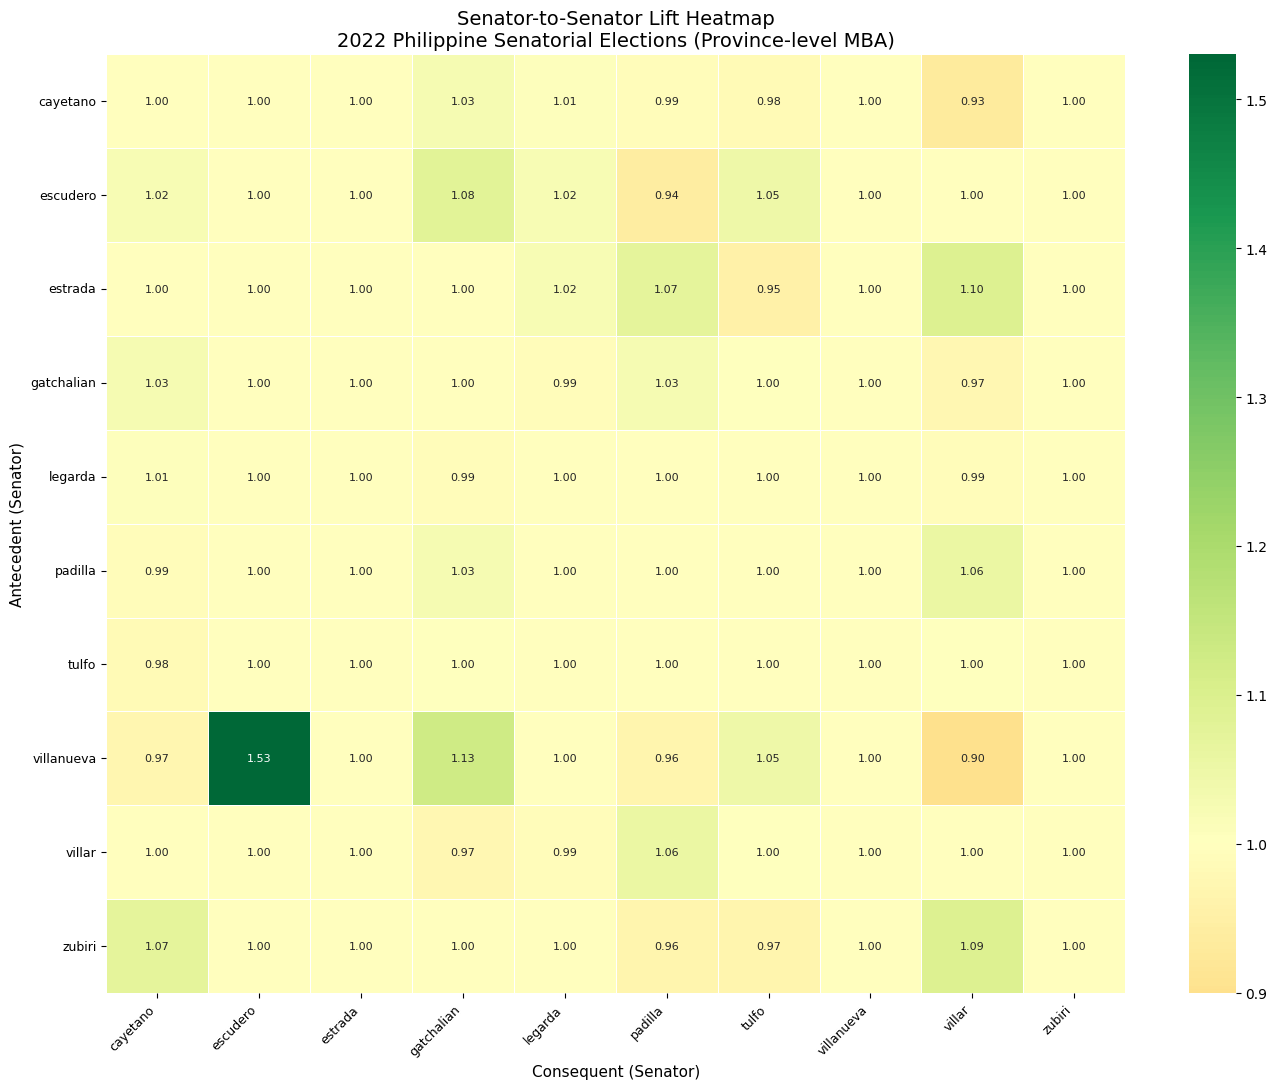

In [27]:
# 3. Plot heatmap
plt.figure(figsize=(14, 11))
sns.heatmap(
    lift_matrix,
    cmap='RdYlGn',
    center=1.0,
    annot=True,
    fmt='.2f',
    linewidths=0.5,
    annot_kws={'size': 8}
)
plt.title('Senator-to-Senator Lift Heatmap\n2022 Philippine Senatorial Elections (Province-level MBA)', fontsize=14)
plt.xlabel('Consequent (Senator)', fontsize=11)
plt.ylabel('Antecedent (Senator)', fontsize=11)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.show()

In [28]:
# 4. Identify strongest and weakest associations
# Exclude diagonal (self-association = 1.0 baseline)
arr = lift_matrix.values.copy()
np.fill_diagonal(arr, np.nan)
lift_matrix = pd.DataFrame(arr, index=lift_matrix.index, columns=lift_matrix.columns)

max_val = lift_matrix.stack().idxmax()
min_val = lift_matrix.stack().idxmin()

print(f'(a) Strongest positive association: {max_val[0]} → {max_val[1]}'
      f' (lift = {lift_matrix.loc[max_val[0], max_val[1]]:.3f})')
print(f'(b) Weakest association: {min_val[0]} → {min_val[1]}'
      f' (lift = {lift_matrix.loc[min_val[0], min_val[1]]:.3f})')

(a) Strongest positive association: villanueva → escudero (lift = 1.530)
(b) Weakest association: villanueva → villar (lift = 0.900)


---

## Task 5 — Interpretation

In [57]:
# 1. Top 3 rules by lift as a markdown table
top3 = filtered_rules[cols].sort_values('lift', ascending=False).head(3).copy()
top3['antecedents'] = top3['antecedents'].apply(lambda x: ', '.join(sorted(x)))
top3['consequents'] = top3['consequents'].apply(lambda x: ', '.join(sorted(x)))
top3['support'] = top3['support'].round(3)
top3['confidence'] = top3['confidence'].round(3)
top3['lift'] = top3['lift'].round(3)
top3.columns = ['Antecedent', 'Consequent', 'Support', 'Confidence', 'Lift']
# display(top3.to_markdown(index=False))
# print(top3.to_markdown(index=False))
top3

,Antecedent,Consequent,Support,Confidence,Lift
739,"legarda, padilla, villanueva","escudero, gatchalian",0.311,0.8,1.714
962,"legarda, padilla, villanueva","escudero, gatchalian, tulfo",0.311,0.8,1.714
946,"legarda, padilla, tulfo, villanueva","escudero, gatchalian",0.311,0.8,1.714


### Voting Bloc Analysis

**2. Voting Bloc Pattern Observed:**

The association rules reveal a clear clustering of senators aligned with the **UniTeam coalition** (Marcos-Duterte slate) — candidates such as Padilla, Tulfo, Marcos, Ejercito, and Villar consistently co-appear across provinces with high lift values, indicating that voters who chose one UniTeam candidate overwhelmingly chose others from the same slate. This aligns with the known dominance of the UniTeam coalition in the 2022 elections, which swept all 12 senatorial seats. In contrast, opposition candidates (Hontiveros, Trillanes, De Lima) appear with lower support and fewer high-lift associations, reflecting their narrower geographic reach. The regional bloc patterns suggest ticket-voting behavior driven by political endorsements rather than individual candidate evaluation.

**3. Limitation of Province-Level Aggregation:**

Using province-level aggregation masks intra-provincial variation — a province may have diverse municipalities where different political blocs dominate locally, yet the aggregated top-8 captures only the provincial majority preference. Using municipality-level transactions would generate ~1,700+ transactions (vs. ~90), potentially revealing finer-grained regional subcultures, stronger local political machine effects, and minority coalition patterns that get averaged out at the provincial level, likely producing more specific and nuanced association rules.